# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3208s 19us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

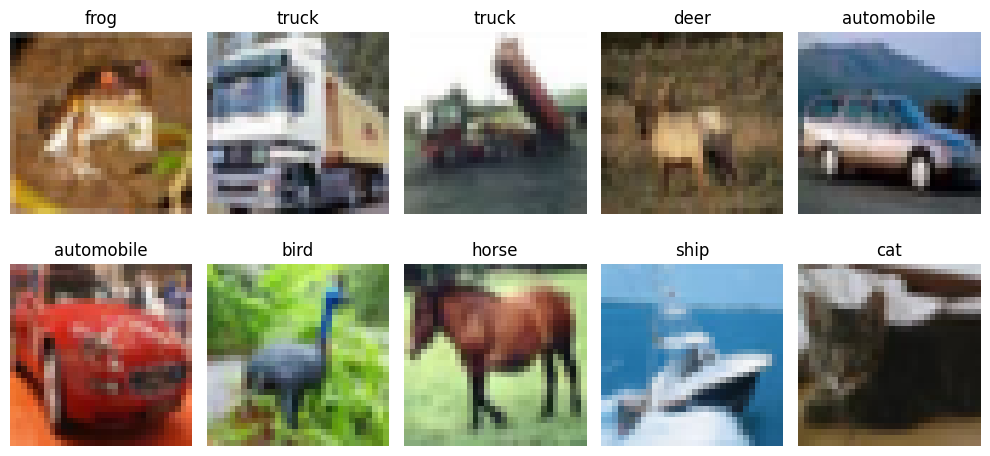

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.2582 - loss: 2.0082 - val_accuracy: 0.3372 - val_loss: 1.8445
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3080 - loss: 1.8845 - val_accuracy: 0.3362 - val_loss: 1.8140
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3331 - loss: 1.8280 - val_accuracy: 0.3688 - val_loss: 1.7829
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3454 - loss: 1.7988 - val_accuracy: 0.3846 - val_loss: 1.7353
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3595 - loss: 1.7695 - val_accuracy: 0.3966 - val_loss: 1.6994
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3660 - loss: 1.7504 - val_accuracy: 0.3896 - val_loss: 1.7004
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.3698 - loss: 1.7381 - val_accuracy: 0.4120 - val_loss: 1.6693
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3739 - loss: 1.7171 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4348 - loss: 1.6331
ANN Test Accuracy: 0.43479999899864197


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 120ms/step - accuracy: 0.4658 - loss: 1.4977 - val_accuracy: 0.5236 - val_loss: 1.3473
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 119ms/step - accuracy: 0.6048 - loss: 1.1343 - val_accuracy: 0.4676 - val_loss: 1.6432
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 118ms/step - accuracy: 0.6633 - loss: 0.9649 - val_accuracy: 0.6584 - val_loss: 0.9790
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 126ms/step - accuracy: 0.7007 - loss: 0.8569 - val_accuracy: 0.6484 - val_loss: 0.9921
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 122ms/step - accuracy: 0.7353 - loss: 0.7633 - val_accuracy: 0.6952 - val_loss: 0.9029
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 120ms/step - accuracy: 0.7603 - loss: 0.6829 - val_accuracy: 0.6856 - val_loss: 0.9376
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.7847 - loss: 0.6199 - val_accuracy: 0.7124 - val_loss: 0.8346
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 123ms/step - accuracy: 0.8024 - lo

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6915 - loss: 1.1015
CNN Test Accuracy: 0.6915000081062317


## 📈 Compare Learning Curves

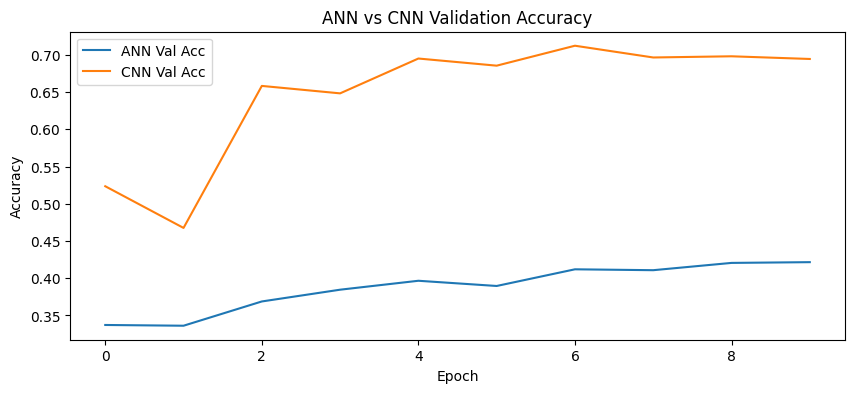

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1, batch_size=64)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 91ms/step - accuracy: 0.3633 - loss: 1.7431 - val_accuracy: 0.5010 - val_loss: 1.4079
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.4590 - loss: 1.4997 - val_accuracy: 0.5568 - val_loss: 1.2412
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.4939 - loss: 1.4102 - val_accuracy: 0.5438 - val_loss: 1.2534
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.5158 - loss: 1.3600 - val_accuracy: 0.5640 - val_loss: 1.2144
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - accuracy: 0.5301 - loss: 1.3230 - val_accuracy: 0.5786 - val_loss: 1.1846
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.5446 - loss: 1.2879 - val_accuracy: 0.6066 - val_loss: 1.1019
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5556 - loss: 1.2590 - val_accuracy: 0.5996 - val_loss: 1.1336
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.5592 - loss: 1.2434 - 

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4348
1,CNN,0.6915


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [12]:
# Task 1: Increase ANN layers
ann_model_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
ann_model_v2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann_v2_history = ann_model_v2.fit(x_train_flat, y_train, epochs=10, validation_split=0.1, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 64ms/step - accuracy: 0.2522 - loss: 2.0294 - val_accuracy: 0.3374 - val_loss: 1.8579
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3045 - loss: 1.8880 - val_accuracy: 0.3466 - val_loss: 1.7883
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3255 - loss: 1.8340 - val_accuracy: 0.3586 - val_loss: 1.7782
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.3420 - loss: 1.8001 - val_accuracy: 0.3678 - val_loss: 1.7594
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - accuracy: 0.3487 - loss: 1.7775 - val_accuracy: 0.3958 - val_loss: 1.7207
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - accuracy: 0.3560 - loss: 1.7648 - val_accuracy: 0.4038 - val_loss: 1.6876
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 68ms/step - accuracy: 0.3635 - loss: 1.7446 - val_accuracy: 0.3984 - val_loss: 1.6680
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3686 - loss: 1.7385 - 

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

adv_aug_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

adv_aug_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

adv_history = adv_aug_model.fit(x_train_norm, y_train, epochs=20,
                                 validation_split=0.1, batch_size=64,
                                 callbacks=[early_stop])

adv_test_loss, adv_test_acc = adv_aug_model.evaluate(x_test_norm, y_test)
print("Advanced Augmented CNN Test Accuracy:", adv_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 103s 142ms/step - accuracy: 0.4114 - loss: 1.6416 - val_accuracy: 0.4532 - val_loss: 1.5368
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 136ms/step - accuracy: 0.5060 - loss: 1.3925 - val_accuracy: 0.5414 - val_loss: 1.2898
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 136ms/step - accuracy: 0.5537 - loss: 1.2711 - val_accuracy: 0.5860 - val_loss: 1.1578
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 137ms/step - accuracy: 0.5811 - loss: 1.1991 - val_accuracy: 0.5480 - val_loss: 1.2999
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 136ms/step - accuracy: 0.6036 - loss: 1.1365 - val_accuracy: 0.6326 - val_loss: 1.0702
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 136ms/step - accuracy: 0.6243 - loss: 1.0790 - val_accuracy: 0.6600 - val_loss: 0.9743
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 140ms/step - accuracy: 0.6379 - loss: 1.0476 - val_accuracy: 0.6652 - val_loss: 0.9786
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 137ms/step - accuracy: 0.6453 - loss

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

In [14]:
# Extended comparison including the student-task models
comparison_extended = pd.DataFrame({
    "Model": ["ANN", "ANN (More Layers)", "CNN", "CNN (Augmented+EarlyStop, 20 epochs)"],
    "Test Accuracy": [ann_test_acc, ann_v2_history.history['val_accuracy'][-1], cnn_test_acc, adv_test_acc]
})
comparison_extended

,Model,Test Accuracy
0,ANN,0.4348
1,ANN (More Layers),0.3942
2,CNN,0.6915
3,"CNN (Augmented+EarlyStop, 20 epochs)",0.7206
